# GradeScope — 04. Trening modeli i reguły symboliczne

**Cel:** trening 4 modeli ML (Pipeline: StandardScaler + model, kalibrowany przez CalibratedClassifierCV), porównanie metryk, ekstrakcja reguł decyzyjnych, wykrywanie anomalii

In [1]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.tree import DecisionTreeClassifier, export_text
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix,
                             ConfusionMatrixDisplay)
import pandas as pd

# Wczytanie danych
with open("../data/splits.pkl", "rb") as f:
    data = pickle.load(f)

with open("../data/selected_features.pkl", "rb") as f:
    selected_features = pickle.load(f)

X_train = data["X_train"][selected_features]
X_test  = data["X_test"][selected_features]
y_train = data["y_train"]
y_test  = data["y_test"]

print(f"Cechy: {len(selected_features)}, Train: {X_train.shape}, Test: {X_test.shape}")

Cechy: 12, Train: (5285, 12), Test: (1322, 12)


## 1. Definicja Pipeline'ów

In [2]:
# CalibratedClassifierCV owijający Pipeline (StandardScaler + model) poprawia kalibrację prawdopodobieństw
def make_calibrated(model):
    base = Pipeline([("scaler", StandardScaler()), ("model", model)])
    return CalibratedClassifierCV(base, cv=5, method="sigmoid")

pipelines = {
    "Random Forest":  make_calibrated(RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)),
    "SVM":            make_calibrated(SVC(kernel="rbf", probability=True, random_state=42)),
    "KNN":            make_calibrated(KNeighborsClassifier(n_neighbors=5)),
    "Neural Network": make_calibrated(MLPClassifier(hidden_layer_sizes=(64, 32), random_state=42, max_iter=500)),
}

print("Zdefiniowane modele:", list(pipelines.keys()))

Zdefiniowane modele: ['Random Forest', 'SVM', 'KNN', 'Neural Network']


## 2. Trening i ocena modeli

In [3]:
results = {}

for name, pipeline in pipelines.items():
    print(f"Trening: {name}...", end=" ")
    pipeline.fit(X_train, y_train)
    y_pred  = pipeline.predict(X_test)
    y_proba = pipeline.predict_proba(X_test)[:, 1]

    results[name] = {
        "Accuracy":  accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall":    recall_score(y_test, y_pred),
        "F1":        f1_score(y_test, y_pred),
        "ROC-AUC":   roc_auc_score(y_test, y_proba),
    }
    print("✓")

print("\nTrening zakończony.")

Trening: Random Forest... 

✓
Trening: SVM... 

✓
Trening: KNN... 

✓
Trening: Neural Network... 

✓

Trening zakończony.


## 3. Porównanie metryk

                Accuracy  Precision  Recall      F1  ROC-AUC
Random Forest     0.8888     0.8934  0.9114  0.9023   0.9570
SVM               0.9085     0.9149  0.9235  0.9192   0.9688
KNN               0.8374     0.8505  0.8631  0.8568   0.9194
Neural Network    0.9168     0.9262  0.9262  0.9262   0.9724


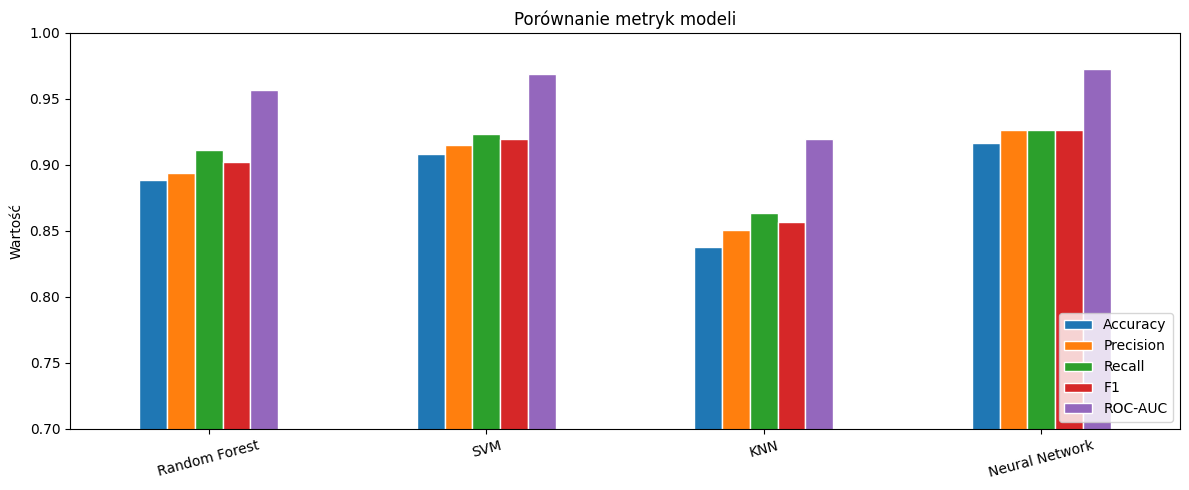

In [4]:
# Tabela porównawcza
df_results = pd.DataFrame(results).T.round(4)
print(df_results.to_string())

# Wykres słupkowy metryk
df_results.plot(kind="bar", figsize=(12, 5), edgecolor="white")
plt.title("Porównanie metryk modeli")
plt.ylabel("Wartość")
plt.xticks(rotation=15)
plt.ylim(0.7, 1.0)
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig("../report/fig_model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

## 4. Macierze pomyłek

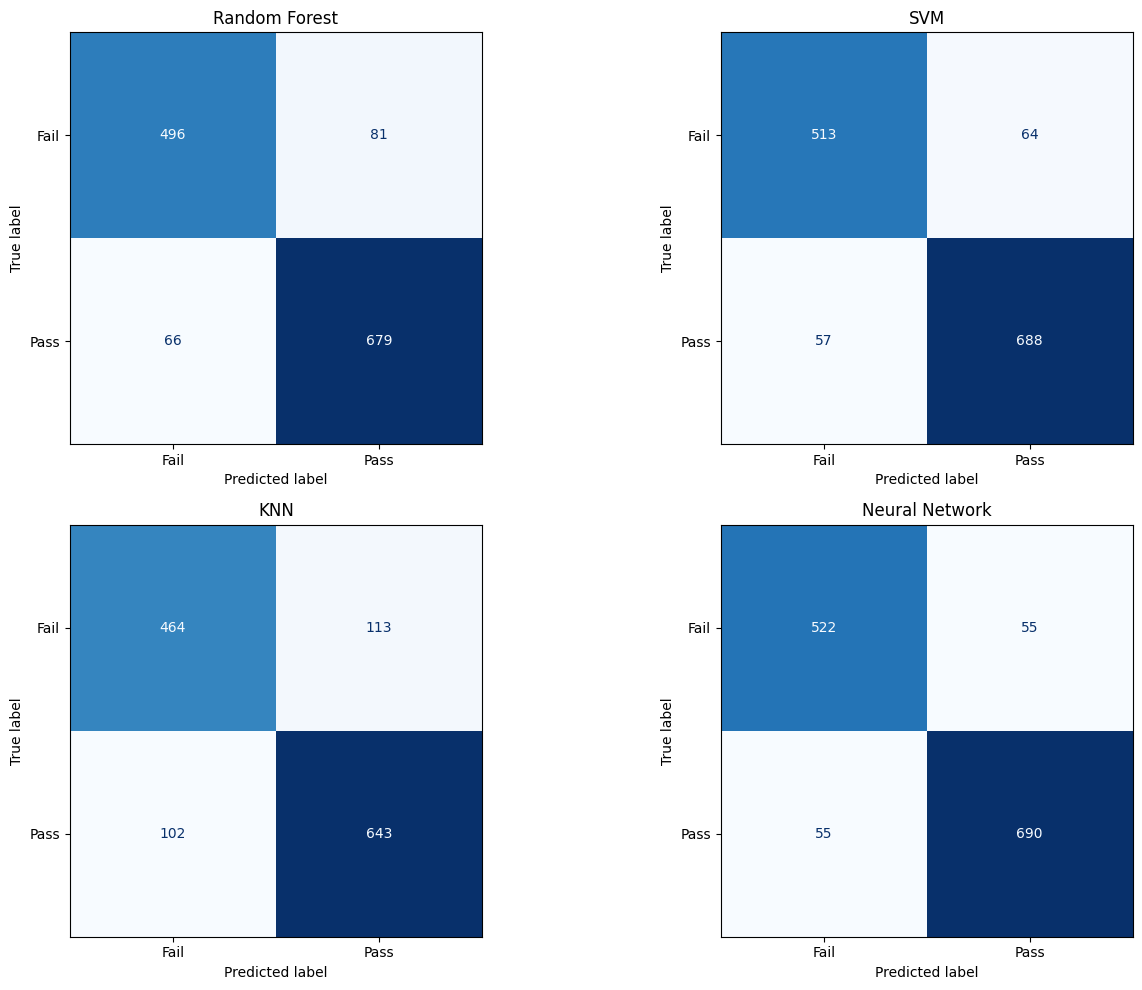

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for ax, (name, pipeline) in zip(axes, pipelines.items()):
    y_pred = pipeline.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=["Fail", "Pass"])
    disp.plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(name)

plt.tight_layout()
plt.savefig("../report/fig_confusion_matrices.png", dpi=150, bbox_inches="tight")
plt.show()

## 5. Reguły symboliczne — drzewo decyzyjne

In [6]:
# Drzewo decyzyjne jako interpreter — shallow tree dla czytelnych reguł
dt = DecisionTreeClassifier(max_depth=4, random_state=42)
dt.fit(X_train, y_train)

dt_acc = accuracy_score(y_test, dt.predict(X_test))
print(f"Accuracy drzewa (max_depth=4): {dt_acc:.4f}\n")
print("Reguły decyzyjne:")
print(export_text(dt, feature_names=selected_features))

Accuracy drzewa (max_depth=4): 0.8245

Reguły decyzyjne:
|--- Attendance <= 79.50
|   |--- Hours_Studied <= 22.50
|   |   |--- Attendance <= 73.50
|   |   |   |--- Hours_Studied <= 17.50
|   |   |   |   |--- class: 0
|   |   |   |--- Hours_Studied >  17.50
|   |   |   |   |--- class: 0
|   |   |--- Attendance >  73.50
|   |   |   |--- Hours_Studied <= 16.50
|   |   |   |   |--- class: 0
|   |   |   |--- Hours_Studied >  16.50
|   |   |   |   |--- class: 0
|   |--- Hours_Studied >  22.50
|   |   |--- Attendance <= 72.50
|   |   |   |--- Hours_Studied <= 27.50
|   |   |   |   |--- class: 0
|   |   |   |--- Hours_Studied >  27.50
|   |   |   |   |--- class: 1
|   |   |--- Attendance >  72.50
|   |   |   |--- Previous_Scores <= 73.50
|   |   |   |   |--- class: 1
|   |   |   |--- Previous_Scores >  73.50
|   |   |   |   |--- class: 1
|--- Attendance >  79.50
|   |--- Hours_Studied <= 14.50
|   |   |--- Attendance <= 89.50
|   |   |   |--- Access_to_Resources <= 0.50
|   |   |   |   |--- cl

In [7]:
import json
from sklearn.tree import _tree

# Rekurencyjne wyodrębnienie reguł z drzewa decyzyjnego
def extract_rules(tree, feature_names):
    tree_ = tree.tree_
    rules = []

    def recurse(node, conditions):
        if tree_.feature[node] != _tree.TREE_UNDEFINED:
            feature   = feature_names[tree_.feature[node]]
            threshold = round(float(tree_.threshold[node]), 2)
            recurse(tree_.children_left[node],  conditions + [{"feature": feature, "operator": "<=", "threshold": threshold}])
            recurse(tree_.children_right[node], conditions + [{"feature": feature, "operator": ">",  "threshold": threshold}])
        else:
            values     = tree_.value[node][0]
            total      = sum(values)
            prediction = int(np.argmax(values))
            confidence = round(float(max(values) / total), 4)
            rules.append({
                "conditions": conditions,
                "prediction": prediction,
                "confidence": confidence,
                "samples":    int(total),
            })

    recurse(0, [])
    return rules

rules = extract_rules(dt, selected_features)
print(f"Liczba reguł: {len(rules)}")

with open("../data/rules.json", "w") as f:
    json.dump(rules, f, indent=2)

print("Zapisano: data/rules.json")

Liczba reguł: 16
Zapisano: data/rules.json


## 6. Wykrywanie anomalii — Isolation Forest

In [8]:
# Isolation Forest — wykrywanie anomalii w danych wejściowych
iso_forest = IsolationForest(n_estimators=100, contamination=0.05, random_state=42)
iso_forest.fit(X_train)

# Ewaluacja — jaki procent zbioru testowego oznaczony jako anomalia?
anomaly_preds = iso_forest.predict(X_test)  # -1 = anomalia, 1 = normalny
anomaly_rate  = (anomaly_preds == -1).mean() * 100
print(f"Anomalie w zbiorze testowym: {anomaly_rate:.1f}% (oczekiwane ~5% przy contamination=0.05)")

# Przykład: kilka rekordów oznaczonych jako anomalie
X_test_reset = X_test.reset_index(drop=True)
anomaly_idx  = X_test_reset[anomaly_preds == -1].index[:5]
print(f"Przykładowe anomalie (pierwsze 5 indeksów): {list(anomaly_idx)}")
print(X_test_reset.loc[anomaly_idx])

Anomalie w zbiorze testowym: 6.0% (oczekiwane ~5% przy contamination=0.05)
Przykładowe anomalie (pierwsze 5 indeksów): [10, 45, 62, 63, 97]
    Attendance  Hours_Studied  Previous_Scores  Tutoring_Sessions  \
10          92             33               67                  6   
45          62             23               51                  5   
62          98             30               50                  0   
63          78             21               60                  3   
97          64             27               58                  2   

    Sleep_Hours  Parental_Involvement  Access_to_Resources  Physical_Activity  \
10            7                     0                    0                  5   
45            6                     2                    2                  2   
62            5                     1                    1                  2   
63           10                     2                    0                  5   
97            8                     0   

## 7. Zapis modeli

In [9]:
# Zapis Pipeline'ów — do eksportu ONNX
model_keys = {
    "Random Forest":  "random_forest",
    "SVM":            "svm",
    "KNN":            "knn",
    "Neural Network": "neural_network",
}

with open("../data/trained_pipelines.pkl", "wb") as f:
    pickle.dump({model_keys[k]: v for k, v in pipelines.items()}, f)

with open("../data/decision_tree.pkl", "wb") as f:
    pickle.dump(dt, f)

with open("../data/anomaly_detector.pkl", "wb") as f:
    pickle.dump(iso_forest, f)

print("Zapisano: trained_pipelines.pkl, decision_tree.pkl, anomaly_detector.pkl")

Zapisano: trained_pipelines.pkl, decision_tree.pkl, anomaly_detector.pkl
